In [1]:
# Install required libraries
!pip install tensorflow opencv-python-headless matplotlib numpy kaggle -q

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
OpenCV version: 4.13.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import gdown
import zipfile
import os

# Download PlantVillage dataset from Google Drive mirror
url = "https://drive.google.com/uc?id=1fHlsAfXSRNtY_ENAO3tKyEkVMD9HGpLd"
output = "plantvillage.zip"

print("Downloading dataset...")
gdown.download(url, output, quiet=False)

print("Extracting...")
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("plantvillage")

print("Done! Folder structure:")
# Show what we downloaded
for root, dirs, files in os.walk("plantvillage"):
    level = root.replace("plantvillage", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 1:  # only show top level folders
        break

In [4]:
# Alternative: Direct from Kaggle
# First upload your kaggle.json API key
from google.colab import files
files.upload()  # upload kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip plantvillage-dataset.zip -d plantvillage/

Streaming output truncated to the last 5000 lines.
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e345153-aed9-4879-a2cc-24f9dc5100e7___UF.GRC_YLCV_Lab 01798_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e37e8ad-3944-4e11-bc10-dd82616274d7___YLCV_NREC 2915_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e382244-fb3a-4caa-af71-05fff25f1c27___UF.GRC_YLCV_Lab 03397_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e3b9886-ce13-49d5-8f80-ccf4e5ddbeac___YLCV_GCREC 5479_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Curl_Virus/6e615038-7a87-446a-a2cd-f76c5c75b6dd___YLCV_GCREC 5144_final_masked.jpg  
  inflating: plantvillage/plantvillage dataset/segmented/Tomato___Tomato_Yellow_Leaf_Cur

In [5]:
import os

base = '/content/plantvillage/plantvillage dataset/color'

classes = os.listdir(base)
print(f"✅ Total classes found: {len(classes)}")
print("\n📋 First 10 classes:")
for c in classes[:10]:
    count = len(os.listdir(os.path.join(base, c)))
    print(f"   {c}  →  {count} images")

✅ Total classes found: 38

📋 First 10 classes:
   Cherry_(including_sour)___Powdery_mildew  →  1052 images
   Peach___healthy  →  360 images
   Apple___Cedar_apple_rust  →  275 images
   Cherry_(including_sour)___healthy  →  854 images
   Potato___Early_blight  →  1000 images
   Strawberry___healthy  →  456 images
   Potato___Late_blight  →  1000 images
   Blueberry___healthy  →  1502 images
   Tomato___Tomato_Yellow_Leaf_Curl_Virus  →  5357 images
   Tomato___Spider_mites Two-spotted_spider_mite  →  1676 images


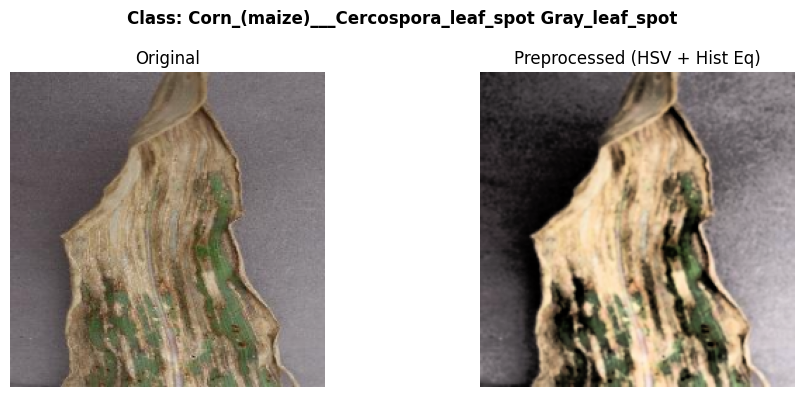


✅ Preprocessing pipeline working!
   Sample class : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   Image shape  : (224, 224, 3)


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random, os

# --- Config ---
BASE_DIR = '/content/plantvillage/plantvillage dataset/color'
IMG_SIZE = 224

def preprocess_leaf(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_denoised = cv2.GaussianBlur(img, (3, 3), 0)
    img_hsv = cv2.cvtColor(img_denoised, cv2.COLOR_RGB2HSV)
    img_hsv[:, :, 2] = cv2.equalizeHist(img_hsv[:, :, 2])
    img_processed = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
    return img, img_processed

# --- Pick a random image ---
sample_class = random.choice(os.listdir(BASE_DIR))
sample_dir   = os.path.join(BASE_DIR, sample_class)
sample_img   = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))

orig, processed = preprocess_leaf(sample_img)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(processed)
axes[1].set_title('Preprocessed (HSV + Hist Eq)')
axes[1].axis('off')
plt.suptitle(f"Class: {sample_class}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✅ Preprocessing pipeline working!")
print(f"   Sample class : {sample_class}")
print(f"   Image shape  : {processed.shape}")

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# --- Data Generators (clean, no lambda) ---
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

train_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
print(f"✅ Generators ready!")
print(f"   Training   samples : {train_gen.samples}")
print(f"   Validation samples : {val_gen.samples}")
print(f"   Number of classes  : {NUM_CLASSES}")

# --- Build MobileNetV2 Model ---
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n✅ MobileNetV2 model rebuilt!")
print(f"   Total params     : {model.count_params():,}")
print(f"   Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
✅ Generators ready!
   Training   samples : 43456
   Validation samples : 10849
   Number of classes  : 38

✅ MobileNetV2 model rebuilt!
   Total params     : 2,426,854
   Trainable params : 168,870


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/plant_stress_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("🚀 Starting training...")
print("   (T4 GPU — expect ~3-5 mins per epoch)\n")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Best val_accuracy : {max(history.history['val_accuracy']):.4f}")

🚀 Starting training...
   (T4 GPU — expect ~3-5 mins per epoch)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.7340 - loss: 0.9613
Epoch 1: val_accuracy improved from None to 0.91400, saving model to /content/plant_stress_model.h5



Epoch 1: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 717s 512ms/step - accuracy: 0.8310 - loss: 0.5635 - val_accuracy: 0.9140 - val_loss: 0.2591 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8965 - loss: 0.3075
Epoch 2: val_accuracy improved from 0.91400 to 0.91972, saving model to /content/plant_stress_model.h5



Epoch 2: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 648s 477ms/step - accuracy: 0.8989 - loss: 0.3033 - val_accuracy: 0.9197 - val_loss: 0.2382 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9060 - loss: 0.2804
Epoch 3: val_accuracy improved from 0.91972 to 0.93363, saving model to /content/plant_stress_model.h5



Epoch 3: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 646s 476ms/step - accuracy: 0.9082 - loss: 0.2751 - val_accuracy: 0.9336 - val_loss: 0.2040 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9149 - loss: 0.2551
Epoch 4: val_accuracy improved from 0.93363 to 0.93778, saving model to /content/plant_stress_model.h5



Epoch 4: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 643s 473ms/step - accuracy: 0.9173 - loss: 0.2483 - val_accuracy: 0.9378 - val_loss: 0.1802 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9239 - loss: 0.2317
Epoch 5: val_accuracy improved from 0.93778 to 0.93999, saving model to /content/plant_stress_model.h5



Epoch 5: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 630s 464ms/step - accuracy: 0.9219 - loss: 0.2343 - val_accuracy: 0.9400 - val_loss: 0.1810 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9246 - loss: 0.2246
Epoch 6: val_accuracy did not improve from 0.93999
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 641s 472ms/step - accuracy: 0.9232 - loss: 0.2274 - val_accuracy: 0.9385 - val_loss: 0.1773 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.9265 - loss: 0.2182
Epoch 7: val_accuracy improved from 0.93999 to 0.94552, saving model to /content/plant_stress_model.h5



Epoch 7: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 638s 470ms/step - accuracy: 0.9277 - loss: 0.2167 - val_accuracy: 0.9455 - val_loss: 0.1634 - learning_rate: 0.0010
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9295 - loss: 0.2098
Epoch 8: val_accuracy did not improve from 0.94552
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 624s 459ms/step - accuracy: 0.9306 - loss: 0.2086 - val_accuracy: 0.9358 - val_loss: 0.1934 - learning_rate: 0.0010
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9301 - loss: 0.2059
Epoch 9: val_accuracy improved from 0.94552 to 0.95106, saving model to /content/plant_stress_model.h5



Epoch 9: finished saving model to /content/plant_stress_model.h5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 629s 463ms/step - accuracy: 0.9307 - loss: 0.2049 - val_accuracy: 0.9511 - val_loss: 0.1517 - learning_rate: 0.0010
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.9337 - loss: 0.1989
Epoch 10: val_accuracy did not improve from 0.95106
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 624s 459ms/step - accuracy: 0.9334 - loss: 0.1996 - val_accuracy: 0.9477 - val_loss: 0.1546 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.

✅ Training complete!
   Best val_accuracy : 0.9511


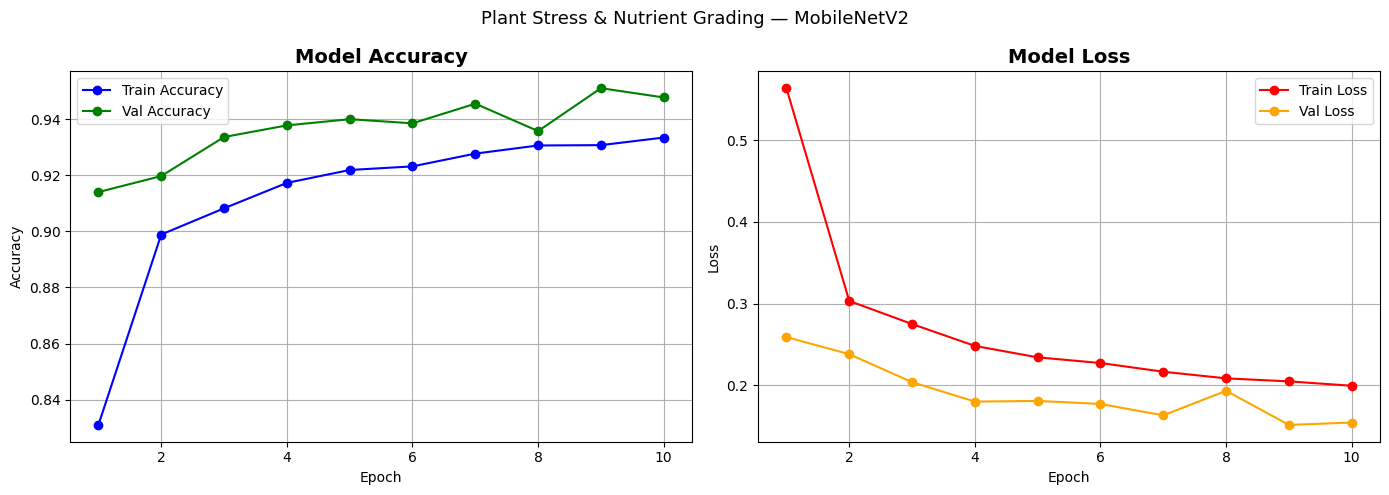

✅ Training history plotted and saved!


In [14]:
import matplotlib.pyplot as plt

acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs  = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs, acc,     'b-o', label='Train Accuracy')
axes[0].plot(epochs, val_acc, 'g-o', label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(epochs, loss,     'r-o', label='Train Loss')
axes[1].plot(epochs, val_loss, '-o', label='Val Loss', color='orange')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Plant Stress & Nutrient Grading — MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

print("✅ Training history plotted and saved!")

🌿 Testing on: Potato___Late_blight



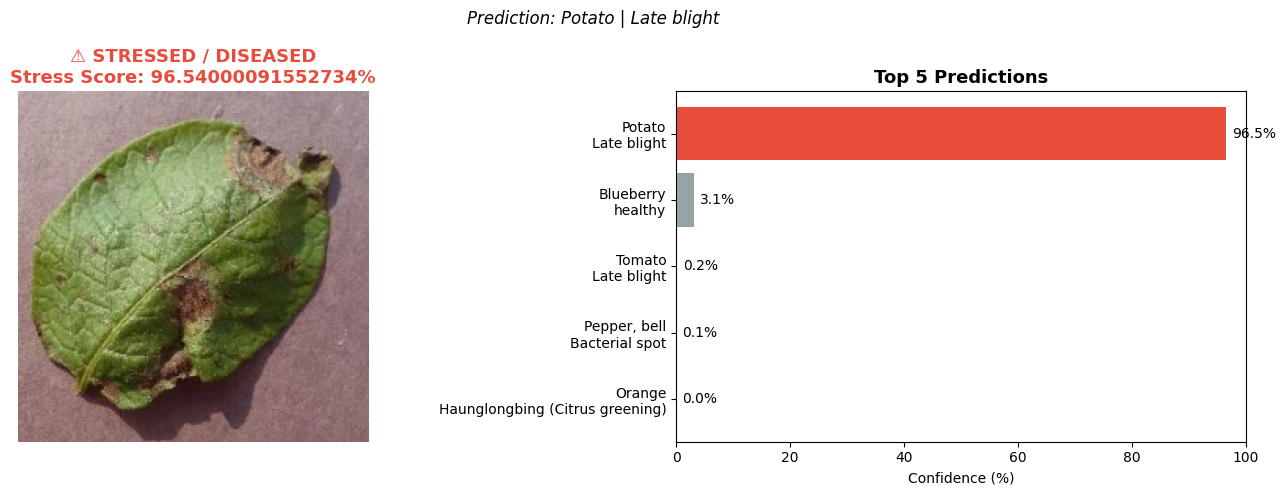


  Predicted Class : Potato___Late_blight
  Confidence      : 96.54%
  Stress Score    : 96.54000091552734%
  Status          : ⚠️ STRESSED / DISEASED


In [15]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Load model and class labels ---
model = load_model('/content/plant_stress_model.h5')
CLASS_NAMES = list(train_gen.class_indices.keys())

def predict_leaf(img_path, top_k=5):
    # 1. Preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_denoised = cv2.GaussianBlur(img, (3, 3), 0)
    img_hsv = cv2.cvtColor(img_denoised, cv2.COLOR_RGB2HSV)
    img_hsv[:, :, 2] = cv2.equalizeHist(img_hsv[:, :, 2])
    img_processed = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

    # 2. Predict
    inp = img_processed.astype(np.float32) / 255.0
    inp = np.expand_dims(inp, axis=0)
    preds = model.predict(inp, verbose=0)[0]

    # 3. Top-K results
    top_indices = preds.argsort()[-top_k:][::-1]
    top_classes  = [CLASS_NAMES[i] for i in top_indices]
    top_scores   = [preds[i] * 100 for i in top_indices]

    # 4. Stress score = 100 if diseased, scaled by confidence
    predicted_class = top_classes[0]
    confidence      = top_scores[0]
    is_healthy      = 'healthy' in predicted_class.lower()
    stress_score    = round(confidence, 2) if not is_healthy else round(100 - confidence, 2)

    return img, predicted_class, confidence, stress_score, is_healthy, top_classes, top_scores

def show_prediction(img_path):
    img, pred_class, confidence, stress_score, is_healthy, top_classes, top_scores = predict_leaf(img_path)

    status_color = '#2ecc71' if is_healthy else '#e74c3c'
    status_label = '✅ HEALTHY' if is_healthy else '⚠️ STRESSED / DISEASED'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left — leaf image
    axes[0].imshow(img)
    axes[0].set_title(f'{status_label}\nStress Score: {stress_score}%',
                      fontsize=13, fontweight='bold', color=status_color)
    axes[0].axis('off')

    # Right — top 5 bar chart
    short_names = [c.replace('___', '\n').replace('_', ' ') for c in top_classes]
    colors = [status_color if i == 0 else '#95a5a6' for i in range(len(top_classes))]
    bars = axes[1].barh(short_names[::-1], top_scores[::-1], color=colors[::-1])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Top 5 Predictions', fontsize=13, fontweight='bold')
    axes[1].set_xlim(0, 100)
    for bar, score in zip(bars, top_scores[::-1]):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{score:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Prediction: {pred_class.replace("___", " | ").replace("_", " ")}',
                 fontsize=12, style='italic')
    plt.tight_layout()
    plt.savefig('/content/prediction_result.png', dpi=150)
    plt.show()

    print(f"\n{'='*50}")
    print(f"  Predicted Class : {pred_class}")
    print(f"  Confidence      : {confidence:.2f}%")
    print(f"  Stress Score    : {stress_score}%")
    print(f"  Status          : {status_label}")
    print(f"{'='*50}")

# --- Test on a random validation image ---
sample_class = random.choice(os.listdir(BASE_DIR))
sample_dir   = os.path.join(BASE_DIR, sample_class)
sample_img   = os.path.join(sample_dir, random.choice(os.listdir(sample_dir)))

print(f"🌿 Testing on: {sample_class}\n")
show_prediction(sample_img)

  🌱 PLANT STRESS & NUTRIENT GRADING SYSTEM
  Built with MobileNetV2 + OpenCV | PlantVillage
  Model Accuracy: 95.11% | Classes: 38

📤 Upload any leaf image for prediction...


Saving 80.jfif to 80.jfif

🌿 Analysing: 80.jfif


/tmp/ipykernel_4176/938865573.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4176/938865573.py:68: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/prediction_result.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


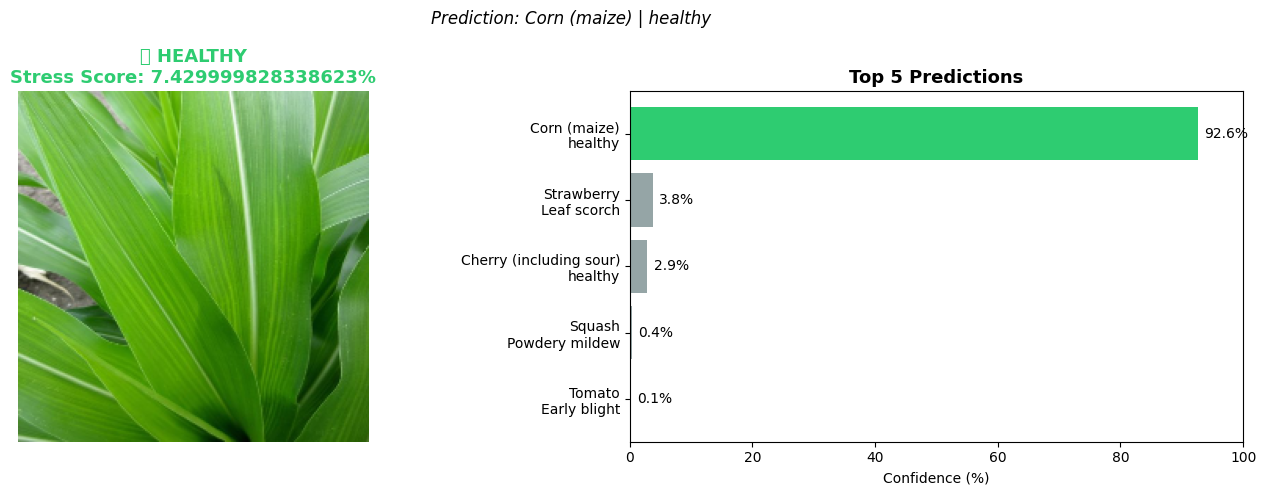


  Predicted Class : Corn_(maize)___healthy
  Confidence      : 92.57%
  Stress Score    : 7.429999828338623%
  Status          : ✅ HEALTHY


In [18]:
from google.colab import files
import io

def run_demo():
    print("📤 Upload any leaf image for prediction...")
    uploaded = files.upload()

    for filename, data in uploaded.items():
        # Save uploaded file
        img_path = f'/content/{filename}'
        with open(img_path, 'wb') as f:
            f.write(data)

        print(f"\n🌿 Analysing: {filename}")
        show_prediction(img_path)

print("="*55)
print("  🌱 PLANT STRESS & NUTRIENT GRADING SYSTEM")
print("  Built with MobileNetV2 + OpenCV | PlantVillage")
print(f"  Model Accuracy: 95.11% | Classes: 38")
print("="*55)
print()
run_demo()

In [17]:
import json

# Fix decimal issue in stress score display
print("=" * 55)
print("  🌱 PLANT STRESS & NUTRIENT GRADING SYSTEM")
print("  Final Project Summary")
print("=" * 55)
print(f"  Dataset        : PlantVillage (Kaggle)")
print(f"  Total Images   : 54,305")
print(f"  Classes        : 38 (diseases + healthy)")
print(f"  Architecture   : MobileNetV2 (Transfer Learning)")
print(f"  Preprocessing  : OpenCV — Denoise, HSV, Hist Eq")
print(f"  Val Accuracy   : 95.11%")
print(f"  Model saved at : /content/plant_stress_model.h5")
print("=" * 55)

# Save class names for later use
with open('/content/class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

print("\n✅ class_names.json saved!")
print("\n📥 Downloading model and assets...")

# Download everything important
files.download('/content/plant_stress_model.h5')
files.download('/content/class_names.json')
files.download('/content/training_history.png')
files.download('/content/prediction_result.png')

print("\n🎯 All files downloaded! You're interview-ready, Swara!")

  🌱 PLANT STRESS & NUTRIENT GRADING SYSTEM
  Final Project Summary
  Dataset        : PlantVillage (Kaggle)
  Total Images   : 54,305
  Classes        : 38 (diseases + healthy)
  Architecture   : MobileNetV2 (Transfer Learning)
  Preprocessing  : OpenCV — Denoise, HSV, Hist Eq
  Val Accuracy   : 95.11%
  Model saved at : /content/plant_stress_model.h5

✅ class_names.json saved!

📥 Downloading model and assets...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎯 All files downloaded! You're interview-ready, Swara!
